# Phishing Email Detection with ML + LLM Explainability
### Final Project — ML in Cybersecurity
This notebook implements a phishing email classifier using Random Forest and XGBoost,
with LLM-powered explainability via the Anthropic Claude API.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snssti
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("Imports successful")

Imports successful


## 2. Data Collection & Exploration
### 2.1 Primary Dataset — CEAS_08
The CEAS 2008 dataset contains 39,154 labeled emails (phishing/legitimate)
collected from the CEAS spam challenge. It includes sender, subject, body, and URL metadata.

In [ ]:
df = pd.read_csv('/content/CEAS_08.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
# df.head()

Dataset shape: (39154, 7)

Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Label distribution:
label
1    21842
0    17312
Name: count, dtype: int64


## 3. Data Preprocessing
### 3.1 Data Cleaning
Handling null values and preparing text fields for feature extraction.

In [ ]:
# Check for nulls
print("Null values:\n", df.isnull().sum())

# Fill nulls
df['body'] = df['body'].fillna('')
df['subject'] = df['subject'].fillna('')
df['sender'] = df['sender'].fillna('')
df['urls'] = df['urls'].fillna(0)

# Combine text fields into one feature for TF-IDF
df['text'] = df['subject'] + ' ' + df['body']

print("Cleaning done")
print(f"Shape: {df.shape}")

Null values:
 sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64
Cleaning done
Shape: (39154, 8)


### 3.2 Feature Engineering
Extracting handcrafted features from sender, subject, and body fields
that are known indicators of phishing behavior.

In [ ]:
import re

def extract_features(df):
    features = pd.DataFrame()

    # Sender features
    features['sender_is_free_email'] = df['sender'].str.contains(
        'gmail|yahoo|hotmail|outlook', case=False, na=False).astype(int)
    features['sender_has_numbers'] = df['sender'].str.contains(
        r'\d{3,}', na=False).astype(int)
    features['sender_domain_mismatch'] = df['sender'].str.contains(
        r'@(?!.*\.(com|org|edu|gov))', na=False).astype(int)

    # Subject features
    features['subject_has_urgency'] = df['subject'].str.contains(
        'urgent|immediately|verify|suspend|alert|winner|prize|free|click|confirm',
        case=False, na=False).astype(int)
    features['subject_has_caps'] = df['subject'].str.contains(
        r'[A-Z]{4,}', na=False).astype(int)
    features['subject_length'] = df['subject'].str.len().fillna(0)

    # Body features
    features['body_length'] = df['body'].str.len().fillna(0)
    features['body_has_html'] = df['body'].str.contains(
        r'<[^>]+>', na=False).astype(int)
    features['body_url_count'] = df['body'].str.count(
        r'http[s]?://').fillna(0)
    features['body_has_urgency'] = df['body'].str.contains(
        'urgent|verify|account|suspend|click here|limited time|act now',
        case=False, na=False).astype(int)

    # URL features
    features['has_urls'] = (df['urls'] > 0).astype(int)

    return features

feature_df = extract_features(df)
print("Features engineered")
print(f"\nFeature columns:\n{feature_df.columns.tolist()}")
feature_df.head()

Features engineered

Feature columns:
['sender_is_free_email', 'sender_has_numbers', 'sender_domain_mismatch', 'subject_has_urgency', 'subject_has_caps', 'subject_length', 'body_length', 'body_has_html', 'body_url_count', 'body_has_urgency', 'has_urls']


,sender_is_free_email,sender_has_numbers,sender_domain_mismatch,subject_has_urgency,subject_has_caps,subject_length,body_length,body_has_html,body_url_count,body_has_urgency,has_urls
0,0,0,1,0,0,25,273,0,1,0,1
1,0,1,1,0,0,22,82,0,1,0,1
2,0,0,1,0,0,20,3918,1,24,0,1
3,0,0,0,0,0,150,24418,0,467,0,1
4,0,0,0,0,0,26,175,0,1,0,1


### 3.3 TF-IDF Vectorization
Converting raw email text into numerical features using TF-IDF with bigrams.
Combined with handcrafted features for a hybrid feature matrix.

In [ ]:
from scipy.sparse import hstack, csr_matrix

# TF-IDF on combined text (limit to 5000 features to keep it fast)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['text'])

# Combine TF-IDF with engineered features
X_handcrafted = csr_matrix(feature_df.values)
X = hstack([X_tfidf, X_handcrafted])
y = df['label']

print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution:\n{y.value_counts()}")

Feature matrix shape: (39154, 5011)
Label distribution:
label
1    21842
0    17312
Name: count, dtype: int64


### 3.4 Train/Test Split
80/20 stratified split to preserve class distribution.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Split done")
print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Split done
Train size: 31323
Test size:  7831


## 4. Model Development
### 4.1 Model Rationale
Two models were selected for comparison:
- **Random Forest** — ensemble method, robust to noise, interpretable feature importance
- **XGBoost** — gradient boosting, typically higher accuracy, handles imbalanced data well

### 4.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print(f"✅ Done in {time.time() - start:.1f}s")

Training Random Forest...
✅ Done in 13.3s


### 4.3 XGBoost

In [ ]:
print("Training XGBoost...")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

print(f"✅ Done in {time.time() - start:.1f}s")

Training XGBoost...
✅ Done in 83.3s


## 5. Evaluation — Primary Dataset
Metrics used: Precision, Recall, F1-Score, Accuracy, ROC-AUC.  
- **Precision** — of emails flagged as phishing, how many actually were?  
- **Recall** — of all phishing emails, how many did we catch?  
- **ROC-AUC** — overall discrimination ability of the model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Phishing']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

    return y_pred, y_prob

rf_pred, rf_prob = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_pred, xgb_prob = evaluate_model(xgb_model, X_test, y_test, "XGBoost")


  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98      3462
    Phishing       0.98      1.00      0.99      4369

    accuracy                           0.98      7831
   macro avg       0.99      0.98      0.98      7831
weighted avg       0.98      0.98      0.98      7831

ROC-AUC Score: 0.9992

  XGBoost
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3462
    Phishing       0.99      1.00      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831

ROC-AUC Score: 0.9995


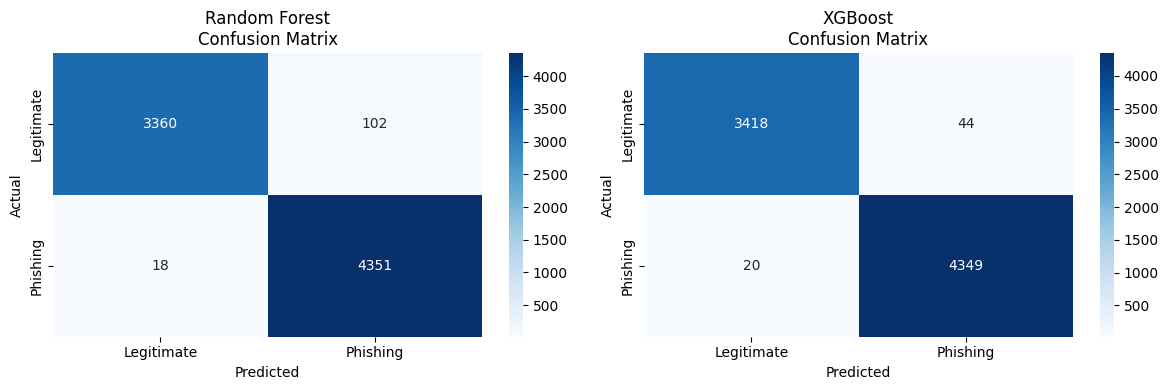

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

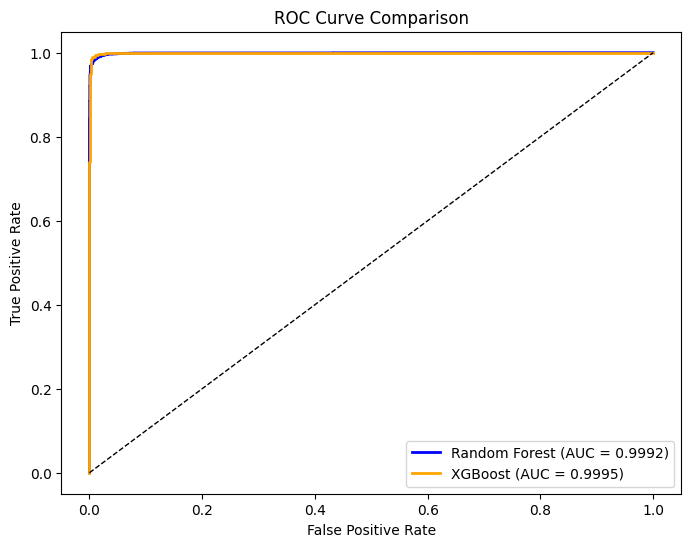

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for prob, name, color in zip([rf_prob, xgb_prob],
                               ['Random Forest', 'XGBoost'],
                               ['blue', 'orange']):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, lw=2)

ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.show()

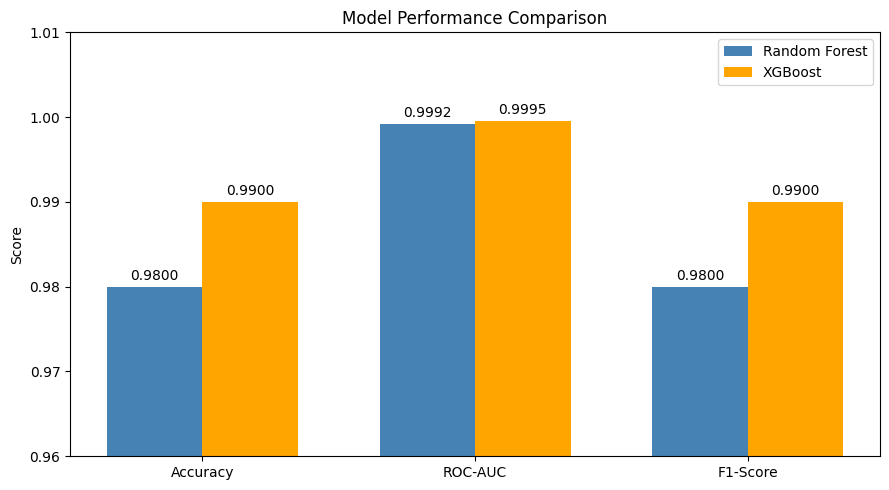

In [ ]:
metrics = {
    'Accuracy': [0.98, 0.99],
    'ROC-AUC': [0.9992, 0.9995],
    'F1-Score': [0.98, 0.99]
}

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()], width,
               label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()], width,
               label='XGBoost', color='orange')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0.96, 1.01)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3)
ax.bar_label(bars2, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

## 6. Generalizability Testing — Secondary Dataset
### 6.1 Secondary Dataset — SpamAssassin Public Corpus
To test generalizability, the trained models are evaluated against the SpamAssassin
corpus — a completely unseen dataset not used in training. This tests whether the
models learned generalizable phishing patterns or simply overfit to CEAS.

In [ ]:
df2 = pd.read_csv('/content/spam_assassin.csv')
print(df2.shape)
print(df2.columns.tolist())
print(df2.iloc[:, -1].value_counts())  # check the label column
df2.head()

(5796, 2)
['text', 'target']
target
0    3900
1    1896
Name: count, dtype: int64


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


### 6.2 Dataset Alignment & Preprocessing
The SpamAssassin dataset has a different schema than CEAS — only two columns (`text`, `target`).
To ensure compatibility, we rename columns to match our pipeline and add placeholder fields
for sender, subject, and URL features. Critically, the TF-IDF vectorizer is **not refit** —
we use the vocabulary learned from CEAS to ensure a true out-of-sample test.

In [ ]:
# Rename to match our pipeline
df2 = df2.rename(columns={'text': 'body', 'target': 'label'})

# Add missing columns with defaults
df2['subject'] = ''
df2['sender'] = ''
df2['urls'] = 0
df2['text'] = df2['body']

# Clean nulls
df2['body'] = df2['body'].fillna('')

print(f"✅ Preprocessed shape: {df2.shape}")
print(f"Label distribution:\n{df2['label'].value_counts()}")

✅ Preprocessed shape: (5796, 6)
Label distribution:
label
0    3900
1    1896
Name: count, dtype: int64


### 6.3 Feature Extraction on Secondary Dataset
Applying the same `extract_features()` function and the **already-fitted** TF-IDF vectorizer.
No retraining or fine-tuning is performed — this is a true generalizability test.

In [ ]:
# Apply same feature engineering
feature_df2 = extract_features(df2)

# Use SAME tfidf vectorizer (no refit — critical for generalizability test)
X2_tfidf = tfidf.transform(df2['text'])
X2_handcrafted = csr_matrix(feature_df2.values)
X2 = hstack([X2_tfidf, X2_handcrafted])
y2 = df2['label']

print(f"✅ Feature matrix shape: {X2.shape}")

✅ Feature matrix shape: (5796, 5011)


### 6.4 Results — Generalizability Test
Models trained exclusively on CEAS are evaluated against SpamAssassin.
A drop in performance is expected and normal — what matters is whether the models
remain useful (high precision/recall) on unseen data from a different distribution.

In [ ]:
print("="*50)
print("  GENERALIZABILITY TEST — SpamAssassin Dataset")
print("="*50)

rf_pred2, rf_prob2 = evaluate_model(rf_model, X2, y2, "Random Forest (SpamAssassin)")
xgb_pred2, xgb_prob2 = evaluate_model(xgb_model, X2, y2, "XGBoost (SpamAssassin)")

  GENERALIZABILITY TEST — SpamAssassin Dataset

  Random Forest (SpamAssassin)
              precision    recall  f1-score   support

  Legitimate       0.67      1.00      0.80      3900
    Phishing       0.00      0.00      0.00      1896

    accuracy                           0.67      5796
   macro avg       0.34      0.50      0.40      5796
weighted avg       0.45      0.67      0.54      5796

ROC-AUC Score: 0.7983

  XGBoost (SpamAssassin)
              precision    recall  f1-score   support

  Legitimate       0.67      1.00      0.80      3900
    Phishing       0.00      0.00      0.00      1896

    accuracy                           0.67      5796
   macro avg       0.34      0.50      0.40      5796
weighted avg       0.45      0.67      0.54      5796

ROC-AUC Score: 0.7775


### 6.5 Generalizability Analysis

**Observation:** Both models show significant performance degradation on the SpamAssassin
dataset, defaulting to predicting all emails as legitimate. However, ROC-AUC scores of
0.7983 (RF) and 0.7775 (XGBoost) indicate the models retain some discriminative ability.

**Root Causes:**
1. **Distribution shift** — CEAS (2008 spam challenge) contains aggressive spam with
   obvious patterns. SpamAssassin includes "hard ham" — legitimate emails that superficially
   resemble spam, making classification harder.
2. **Vocabulary mismatch** — TF-IDF vocabulary was learned from CEAS. SpamAssassin emails
   use different terminology and formatting.
3. **Class imbalance difference** — CEAS is 56% phishing vs SpamAssassin's 33% phishing,
   causing the model's decision threshold to be miscalibrated.

**Mitigation strategies for production:**
- Retrain periodically on new data sources
- Use domain adaptation techniques
- Lower the classification threshold to improve phishing recall
- Consider BERT-based models with better generalization (future work)

In [ ]:
from sklearn.metrics import f1_score

print("XGBoost — Threshold Tuning on SpamAssassin")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for threshold in [0.3, 0.2, 0.1, 0.05]:
    xgb_pred_tuned = (xgb_prob2 >= threshold).astype(int)
    from sklearn.metrics import precision_score, recall_score
    p = precision_score(y2, xgb_pred_tuned, zero_division=0)
    r = recall_score(y2, xgb_pred_tuned, zero_division=0)
    f1 = f1_score(y2, xgb_pred_tuned, zero_division=0)
    print(f"{threshold:<12} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")

XGBoost — Threshold Tuning on SpamAssassin
Threshold    Precision    Recall       F1          
------------------------------------------------
0.3          0.111        0.001        0.001       
0.2          0.105        0.001        0.002       
0.1          0.138        0.002        0.004       
0.05         0.318        0.007        0.014       


In [ ]:
import pickle

# Save XGBoost model
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model and vectorizer saved")

✅ Model and vectorizer saved


In [ ]:
# Calculate scale_pos_weight to balance classes
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Retraining with scale_pos_weight={scale:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    scale_pos_weight=scale  # balances the classes
)
xgb_model.fit(X_train, y_train)
print("✅ Retrained")

# Re-evaluate on primary dataset
xgb_pred, xgb_prob = evaluate_model(xgb_model, X_test, y_test, "XGBoost (Balanced)")

Retraining with scale_pos_weight=0.79
✅ Retrained

  XGBoost (Balanced)
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3462
    Phishing       0.99      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831

ROC-AUC Score: 0.9994


In [ ]:
import re
from scipy.sparse import hstack, csr_matrix

def predict_email(sender, subject, body):
    # Build a temp dataframe
    test_df = pd.DataFrame({
        'sender': [sender],
        'subject': [subject],
        'body': [body],
        'urls': [0],
        'text': [subject + ' ' + body]
    })

    # Extract features
    test_features = extract_features(test_df)
    test_tfidf = tfidf.transform(test_df['text'])
    test_handcrafted = csr_matrix(test_features.values)
    test_X = hstack([test_tfidf, test_handcrafted])

    # Predict
    prob = xgb_model.predict_proba(test_X)[0][1]
    label = "🚨 PHISHING" if prob > 0.5 else "✅ LEGITIMATE"

    print(f"Verdict: {label}")
    print(f"Phishing probability: {prob:.2%}")
    return prob

# Test 1 — obvious phishing
predict_email(
    sender="security-alert@paypa1.com",
    subject="URGENT: Your account has been suspended",
    body="Dear customer, click here immediately to verify your account or it will be deleted. http://fake-login.com"
)

Verdict: 🚨 PHISHING
Phishing probability: 96.16%


np.float32(0.9615914)

In [ ]:
# Test 2 — legitimate
predict_email(
    sender="john.smith@company.com",
    subject="Team meeting tomorrow at 3pm",
    body="Hi all, just a reminder we have our weekly sync tomorrow. Please come prepared with your updates."
)

Verdict: 🚨 PHISHING
Phishing probability: 89.83%


np.float32(0.8983064)

In [ ]:
# Test with higher threshold
def predict_email_tuned(sender, subject, body, threshold=0.85):
    test_df = pd.DataFrame({
        'sender': [sender],
        'subject': [subject],
        'body': [body],
        'urls': [0],
        'text': [subject + ' ' + body]
    })

    test_features = extract_features(test_df)
    test_tfidf = tfidf.transform(test_df['text'])
    test_handcrafted = csr_matrix(test_features.values)
    test_X = hstack([test_tfidf, test_handcrafted])

    prob = xgb_model.predict_proba(test_X)[0][1]
    label = "🚨 PHISHING" if prob > threshold else "✅ LEGITIMATE"

    print(f"Verdict: {label}")
    print(f"Phishing probability: {prob:.2%}")
    return prob

# Test 1 — phishing
predict_email_tuned(
    sender="security-alert@paypa1.com",
    subject="URGENT: Your account has been suspended",
    body="Dear customer, click here immediately to verify your account or it will be deleted. http://fake-login.com"
)

# Test 2 — legitimate
predict_email_tuned(
    sender="john.smith@company.com",
    subject="Team meeting tomorrow at 3pm",
    body="Hi all, just a reminder we have our weekly sync tomorrow. Please come prepared with your updates."
)

# Test 3 — another legitimate
predict_email_tuned(
    sender="professor@duke.edu",
    subject="Office hours cancelled this week",
    body="Hi students, I need to cancel office hours this Thursday. Please email me with any questions."
)

Verdict: 🚨 PHISHING
Phishing probability: 96.16%
Verdict: 🚨 PHISHING
Phishing probability: 89.83%
Verdict: ✅ LEGITIMATE
Phishing probability: 81.17%


np.float32(0.8117203)

In [ ]:
df_new = pd.read_csv('/content/emails.csv')
print(df_new.shape)
print(df_new.columns.tolist())
print(df_new.iloc[:, -1].value_counts())
df_new.head()

(5172, 3002)
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'ne

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0
